# Adversarial Attack
- Fast Gradient Sign Method

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset

# 1. 데이터 생성
X, y = make_classification(n_samples=10000, n_features=20, n_informative=15, n_classes=2, random_state=42)
X = X.astype(np.float32)
y = y.astype(np.int64)

# 2. 데이터 분할 (train:val:test = 64:16:20)
# 데이터 분할에서 val 추가
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

# 3. 정규화 (train 기준으로 fit)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Tensor 변환
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# 데이터 로더 정의
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=128)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=128)



In [2]:
# 4. 모델 정의
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleNN(20).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# 학습 루프
best_val_acc = 0
best_model = None
train_losses, val_losses, val_accuracies = [], [], []
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    # validation
    model.eval()
    val_preds, val_labels = [], []
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            output = model(xb)
            val_loss += criterion(output, yb).item()
            val_preds.extend(torch.argmax(output, dim=1).cpu().numpy())
            val_labels.extend(yb.cpu().numpy())
    acc = accuracy_score(val_labels, val_preds)
    val_accuracies.append(acc)
    val_losses.append(val_loss / len(val_loader))

    if acc > best_val_acc:
        best_val_acc = acc
        best_model = model.state_dict()
        best_epoch = epoch


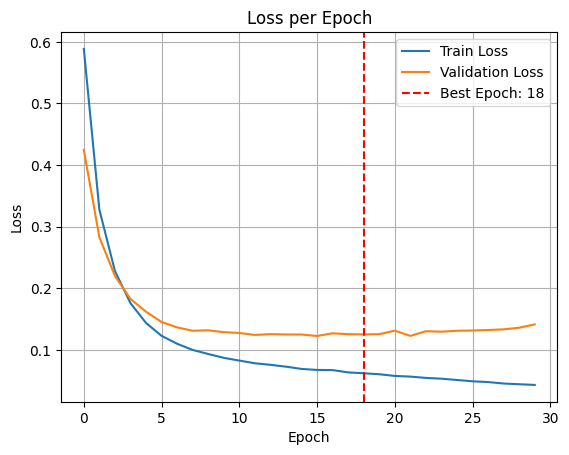

In [3]:
# 시각화
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.axvline(best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
# 5. 테스트 정확도 평가
model.load_state_dict(best_model)
model.eval()
test_preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        output = model(xb)
        test_preds.extend(torch.argmax(output, dim=1).cpu().numpy())
test_acc = accuracy_score(y_test, test_preds)
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9635


Epsilon: 0.000, Accuracy: 0.9635
Epsilon: 0.010, Accuracy: 0.9575
Epsilon: 0.050, Accuracy: 0.9345
Epsilon: 0.100, Accuracy: 0.8805
Epsilon: 0.200, Accuracy: 0.7055


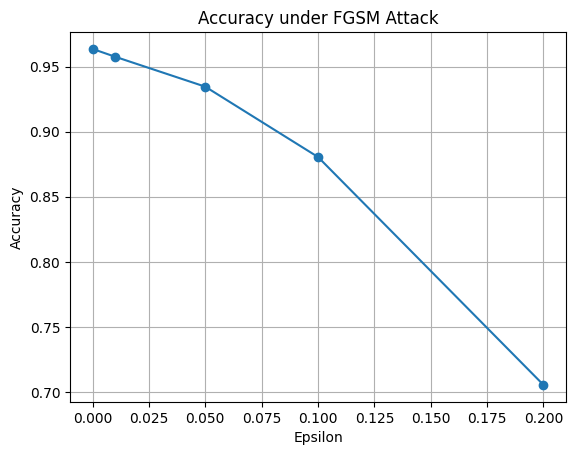

In [5]:
# 6. FGSM 공격 함수 정의
def fgsm_attack(model, x, y, epsilon, criterion):
    x = x.clone().detach().requires_grad_(True)           # ← 안전하게 변경
    output = model(x)
    loss = criterion(output, y)
    model.zero_grad()
    loss.backward()
    x_grad = x.grad.data.sign()
    x_adv = x + epsilon * x_grad
    return x_adv.detach()

# 7. epsilon 별 정확도 측정
epsilons = [0, 0.01, 0.05, 0.1, 0.2]
acc_list = []

for eps in epsilons:
    preds, labels = [], []
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        if eps != 0:
            xb = fgsm_attack(model, xb.clone(), yb, eps, criterion)
        output = model(xb)
        pred = output.argmax(dim=1)
        preds.extend(pred.cpu().numpy())
        labels.extend(yb.cpu().numpy())
    acc = accuracy_score(labels, preds)
    acc_list.append(acc)
    print(f"Epsilon: {eps:.3f}, Accuracy: {acc:.4f}")

# 정확도 시각화
plt.figure()
plt.plot(epsilons, acc_list, marker='o')
plt.title("Accuracy under FGSM Attack")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Adversarial Defense

In [6]:
# 4. Adversarial training loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_defense = SimpleNN(20).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_defense.parameters(), lr=0.001)

best_val_acc = 0
num_epochs = 10
epsilon = 0.1

for epoch in range(num_epochs):
    model_defense.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # clean
        output_clean = model_defense(xb)
        loss_clean = criterion(output_clean, yb)

        # Adversarial Training *************************
        xb_adv = fgsm_attack(model_defense, xb.clone(), yb, epsilon, criterion)
        output_adv = model_defense(xb_adv)
        loss_adv = criterion(output_adv, yb)

        # total loss = clean + adversarial
        alpha = 0.7
        loss = alpha * loss_clean + (1-alpha) * loss_adv
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # validation
    model_defense.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            output = model_defense(xb)
            preds = output.argmax(dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(yb.cpu().numpy())
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"[Epoch {epoch+1}] Loss: {total_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = model_defense.state_dict()
        best_epoch = epoch

print(f"Best Epoch: {best_epoch+1}, Best Validation Accuracy: {best_val_acc:.4f}")

[Epoch 1] Loss: 28.6980, Val Acc: 0.8425
[Epoch 2] Loss: 18.0780, Val Acc: 0.9044
[Epoch 3] Loss: 12.7546, Val Acc: 0.9325
[Epoch 4] Loss: 9.8359, Val Acc: 0.9494
[Epoch 5] Loss: 8.3079, Val Acc: 0.9506
[Epoch 6] Loss: 7.4236, Val Acc: 0.9544
[Epoch 7] Loss: 6.9194, Val Acc: 0.9600
[Epoch 8] Loss: 6.5770, Val Acc: 0.9587
[Epoch 9] Loss: 6.1932, Val Acc: 0.9613
[Epoch 10] Loss: 6.0464, Val Acc: 0.9613
Best Epoch: 9, Best Validation Accuracy: 0.9613


In [7]:
# 테스트 정확도 평가 함수
def evaluate_under_attack(model, test_loader, epsilons, criterion, device):
    model.eval()
    acc_list = []
    for eps in epsilons:
        correct, total = 0, 0
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            if eps > 0:
                xb = fgsm_attack(model, xb.clone(), yb, eps, criterion)
            output = model(xb)
            preds = output.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
        acc = correct / total
        acc_list.append(acc)
        print(f"Epsilon: {eps:.2f}, Accuracy: {acc:.4f}")
    return acc_list

Epsilon: 0.00, Accuracy: 0.9635
Epsilon: 0.01, Accuracy: 0.9575
Epsilon: 0.05, Accuracy: 0.9345
Epsilon: 0.10, Accuracy: 0.8805
Epsilon: 0.15, Accuracy: 0.8025
Epsilon: 0.20, Accuracy: 0.7055
Epsilon: 0.00, Accuracy: 0.9690
Epsilon: 0.01, Accuracy: 0.9620
Epsilon: 0.05, Accuracy: 0.9395
Epsilon: 0.10, Accuracy: 0.8970
Epsilon: 0.15, Accuracy: 0.8500
Epsilon: 0.20, Accuracy: 0.7810


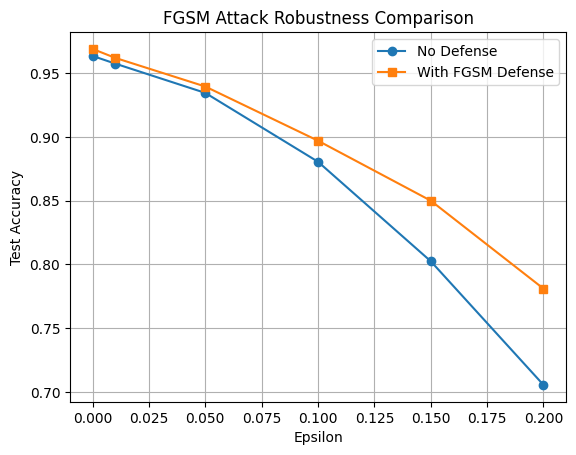

In [8]:
# Epsilon 리스트
epsilons = [0, 0.01, 0.05, 0.1, 0.15, 0.2]

# 모델 및 criterion 준비
model.eval()
model_defense.eval()
criterion = nn.CrossEntropyLoss()

# 정확도 계산
acc_no_defense = evaluate_under_attack(model, test_loader, epsilons, criterion, device)
acc_defense = evaluate_under_attack(model_defense, test_loader, epsilons, criterion, device)

# 결과 시각화
plt.plot(epsilons, acc_no_defense, marker='o', label='No Defense')
plt.plot(epsilons, acc_defense, marker='s', label='With FGSM Defense')
plt.xlabel("Epsilon")
plt.ylabel("Test Accuracy")
plt.title("FGSM Attack Robustness Comparison")
plt.grid(True)
plt.legend()
plt.show()


Best Epoch: 10, Best Val MSE: 391.2395
Epsilon: 0.00, MSE: 365.3136
Epsilon: 0.01, MSE: 560.3293
Epsilon: 0.05, MSE: 1939.5822
Epsilon: 0.10, MSE: 4914.9533
Epsilon: 0.20, MSE: 14503.1032


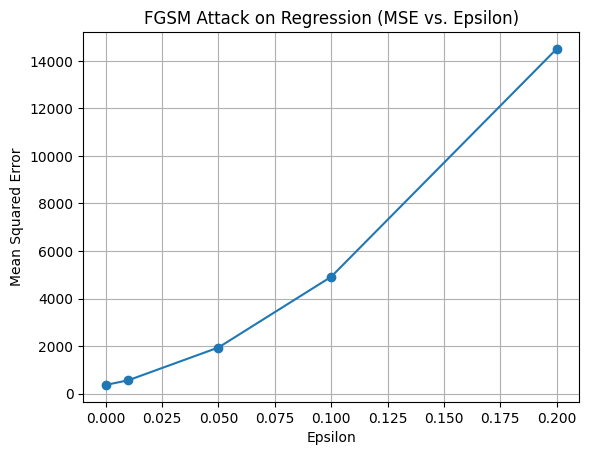

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 생성 및 전처리
X, y = make_regression(n_samples=10000, n_features=20, noise=10.0, random_state=42)
X = X.astype(np.float32)
y = y.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Tensor 변환
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=128)   # ← 추가
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=128)

# 2. 회귀 모델 정의
class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# 3. FGSM 함수 (회귀용)
def fgsm_attack_regression(model, x, y, epsilon, criterion):
    x.requires_grad = True
    output = model(x)
    loss = criterion(output, y)
    model.zero_grad()
    loss.backward()
    grad = x.grad.data.sign()
    x_adv = x + epsilon * grad
    return x_adv.detach()


val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=128)

# 4. 학습 (best model 저장)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RegressionNN(20).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_val_mse = float('inf')
best_model = None
best_epoch = 0

for epoch in range(10):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        output = model(xb)
        loss = criterion(output, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # validation
    model.eval()
    val_preds, val_trues = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_preds.extend(model(xb).cpu().numpy().flatten())
            val_trues.extend(yb.cpu().numpy().flatten())
    val_mse = mean_squared_error(val_trues, val_preds)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_model = model.state_dict()
        best_epoch = epoch

print(f"Best Epoch: {best_epoch+1}, Best Val MSE: {best_val_mse:.4f}")

# 5. epsilon별 FGSM 공격 성능 비교 (MSE로)
epsilons = [0, 0.01, 0.05, 0.1, 0.2]
mse_results = []

model.eval()
for eps in epsilons:
    preds, trues = [], []
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        if eps > 0:
            xb = fgsm_attack_regression(model, xb.clone(), yb, eps, criterion)
        with torch.no_grad():
            pred = model(xb)
        preds.extend(pred.cpu().numpy().flatten())
        trues.extend(yb.cpu().numpy().flatten())
    mse = mean_squared_error(trues, preds)
    print(f"Epsilon: {eps:.2f}, MSE: {mse:.4f}")
    mse_results.append(mse)

# 6. 시각화
plt.plot(epsilons, mse_results, marker='o')
plt.title("FGSM Attack on Regression (MSE vs. Epsilon)")
plt.xlabel("Epsilon")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()

In [13]:
# 모델 초기화
model_defense = RegressionNN(20).to(device)
optimizer = torch.optim.Adam(model_defense.parameters(), lr=0.001)
criterion = nn.MSELoss()
num_epochs = 10
epsilon = 0.1
alpha = 0.7  # clean vs. adversarial loss 비율

# Adversarial Training Loop
for epoch in range(num_epochs):
    model_defense.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # 1. clean loss
        output_clean = model_defense(xb)
        loss_clean = criterion(output_clean, yb)

        # 2. adversarial loss
        xb_adv = fgsm_attack_regression(model_defense, xb.clone(), yb, epsilon, criterion)
        output_adv = model_defense(xb_adv)
        loss_adv = criterion(output_adv, yb)

        # 3. total loss
        loss = alpha * loss_clean + (1 - alpha) * loss_adv
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"[Epoch {epoch+1}] Total Loss: {total_loss:.4f}")


[Epoch 1] Total Loss: 2008753.4961
[Epoch 2] Total Loss: 1958960.8320
[Epoch 3] Total Loss: 1751468.8203
[Epoch 4] Total Loss: 1287092.8379
[Epoch 5] Total Loss: 685801.0005
[Epoch 6] Total Loss: 264829.5881
[Epoch 7] Total Loss: 119441.2258
[Epoch 8] Total Loss: 90960.2549
[Epoch 9] Total Loss: 85730.4366
[Epoch 10] Total Loss: 83646.3263


[RegressionNN] Eps=0.00 → MSE: 365.3136
[RegressionNN] Eps=0.01 → MSE: 560.3293
[RegressionNN] Eps=0.05 → MSE: 1939.5822
[RegressionNN] Eps=0.10 → MSE: 4914.9533
[RegressionNN] Eps=0.20 → MSE: 14503.1032
[RegressionNN] Eps=0.00 → MSE: 362.8953
[RegressionNN] Eps=0.01 → MSE: 543.6711
[RegressionNN] Eps=0.05 → MSE: 1838.8697
[RegressionNN] Eps=0.10 → MSE: 4664.4884
[RegressionNN] Eps=0.20 → MSE: 13950.0600


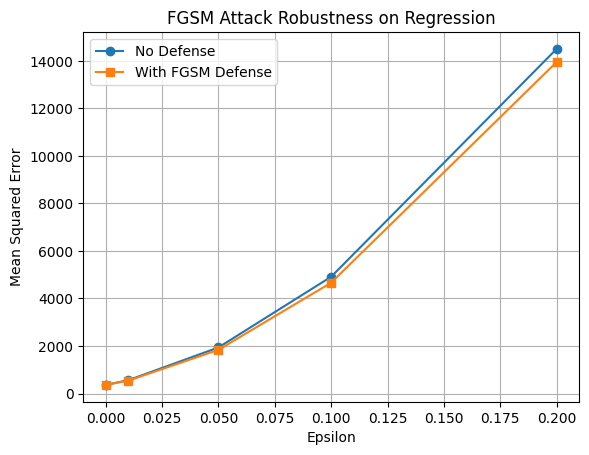

In [14]:
# FGSM MSE 평가 함수
def evaluate_mse(model, test_loader, epsilons):
    model.eval()
    mse_list = []
    for eps in epsilons:
        preds, trues = [], []
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            if eps > 0:
                xb = fgsm_attack_regression(model, xb.clone(), yb, eps, criterion)
            with torch.no_grad():
                pred = model(xb)
            preds.extend(pred.cpu().numpy().flatten())
            trues.extend(yb.cpu().numpy().flatten())
        mse = mean_squared_error(trues, preds)
        mse_list.append(mse)
        print(f"[{model.__class__.__name__}] Eps={eps:.2f} → MSE: {mse:.4f}")
    return mse_list

# 비교 수행
model.eval()
model_defense.eval()
epsilons = [0, 0.01, 0.05, 0.1, 0.2]

mse_no_defense = evaluate_mse(model, test_loader, epsilons)
mse_defense = evaluate_mse(model_defense, test_loader, epsilons)

# 시각화
plt.plot(epsilons, mse_no_defense, marker='o', label='No Defense')
plt.plot(epsilons, mse_defense, marker='s', label='With FGSM Defense')
plt.title("FGSM Attack Robustness on Regression")
plt.xlabel("Epsilon")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.legend()
plt.show()


1. 입력 → 출력까지 곱셈과 비선형 누적 구조
- 딥러닝은 여러 개의 Wx + b와 ReLU, BatchNorm 등을 거쳐 신호를 전달
- 이 과정은 수학적으로 매우 민감한 함수처럼 작동
- 특히 high-dimensional input일수록, 작은 변화가 전체 출력에 큰 누적 영향

2. Gradient 방향으로 움직인다는 점
- FGSM은 단순히 "입력을 무작위로 흔드는 것"이 아니라, 모델이 가장 민감한 방향(∇ₓL) 으로 이동
- 즉, 입력을 가장 효과적으로 망치는 방향을 계산해서 이동
- 결과적으로 사람이 보기엔 거의 차이가 없지만, 모델 입장에서는 큰 차이가 생김

3. CrossEntropy의 민감한 특성
- 분류에서 사용하는 CrossEntropy는 log(softmax)의 조합이라, 어떤 class에 대한 logit이 아주 조금만 바뀌어도 확률 분포 전체가 요동치고 loss가 크게 바뀔수 있음 즉, 클래스가 flip되기 쉬움 → 성공적인 공격
- 참고: PyTorch나 TensorFlow의 CrossEntropyLoss는 내부적으로 softmax 연산을 포함